# Lab 1: Simulation and Modeling — Chemical Reaction Kinetics

**Name:** Manu Sharan Kumar
**Roll No:** ACE080BCT037

## Objective
To simulate the time evolution of several chemical/physical reaction systems using numerical
(Euler-method) integration of their rate equations, and to visualize how the concentrations of
reactants and products change with time.


## Theory

**Chemical kinetics** is the study of the rates of chemical reactions and the factors (concentration,
temperature, catalysts, etc.) that affect them. The rate of a reaction is generally expressed as a
rate law, e.g. for an elementary reaction $aA + bB \rightarrow cC$:

$$ \text{Rate} = k[A]^a[B]^b $$

where $k$ is the rate constant.

**Numerical simulation (Euler's Method).** Most reaction-rate systems are described by coupled,
non-linear ordinary differential equations (ODEs) that do not have simple closed-form solutions.
We approximate the solution by discretizing time into small steps $\Delta t$ and updating each
concentration using:

$$ y_{n+1} = y_n + \frac{dy}{dt}\Big|_{n} \cdot \Delta t $$

This first-order numerical integration scheme is simple to implement and, for small enough
$\Delta t$, gives a good approximation of the true continuous-time behaviour of the system.

In this lab we simulate four different reacting systems:

1. **Reaction 1** — A reversible, second-order reaction $A + B \rightleftharpoons 2C$.
2. **Reaction 2** — The industrial Haber–Bosch ammonia synthesis, $N_2 + 3H_2 \rightleftharpoons 2NH_3$.
3. **Reaction 3** — A two-compartment pharmacokinetic (drug absorption/elimination) model.
4. **Reaction 4** — A simplified nuclear fusion (hydrogen → helium) model.


---
## Reaction 1: Reversible Reaction $A + B \rightleftharpoons 2C$

### Theory

Consider the reversible, second-order reaction:

$$ A + B \underset{k_b}{\overset{k_f}{\rightleftharpoons}} 2C $$

The net forward rate is $r = k_f[A][B] - k_b[C]^2$. Since one mole each of $A$ and $B$ is consumed,
and two moles of $C$ are produced, per unit reaction:

$$ \frac{d[A]}{dt} = -r, \qquad \frac{d[B]}{dt} = -r, \qquad \frac{d[C]}{dt} = +2r $$

Starting from $[A]_0 = 50$, $[B]_0 = 25$, $[C]_0 = 0$ (mol), the system evolves toward an
equilibrium where the forward and backward rates balance ($r \to 0$).

> **Note:** The rate constants $k_f = 0.05$ and $k_b = 0.001$ used below were chosen so that the
> simulated equilibrium concentrations ($[A]\approx 27$, $[B]\approx 2$, $[C]\approx 47$ mol at
> $t = 3\,s$) match the reaction profile described for this system.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Rate constants ---
k_f = 0.05     # Forward rate constant
k_b = 0.001    # Backward rate constant
dt = 0.01      # Time step (s)
steps = 300    # Number of steps -> total time = 3.0 s

# --- Initial concentrations (mol) ---
c1 = [50.0]   # [A]
c2 = [25.0]   # [B]
c3 = [0.0]    # [C]

for i in range(steps):
    # Net forward rate: r = kf*[A][B] - kb*[C]^2
    r = k_f * c1[i] * c2[i] - k_b * c3[i]**2

    dc1 = -r
    dc2 = -r
    dc3 = 2 * r

    c1_next = max(0.0, c1[i] + dc1 * dt)
    c2_next = max(0.0, c2[i] + dc2 * dt)
    c3_next = max(0.0, c3[i] + dc3 * dt)

    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

time_points = np.arange(0, (steps + 1) * dt, dt)

print(f"Initial concentrations : [A]={c1[0]}, [B]={c2[0]}, [C]={c3[0]}")
print(f"Final concentrations   : [A]={c1[-1]:.2f}, [B]={c2[-1]:.2f}, [C]={c3[-1]:.2f}")


Initial concentrations : [A]=50.0, [B]=25.0, [C]=0.0
Final concentrations   : [A]=26.75, [B]=1.75, [C]=46.50


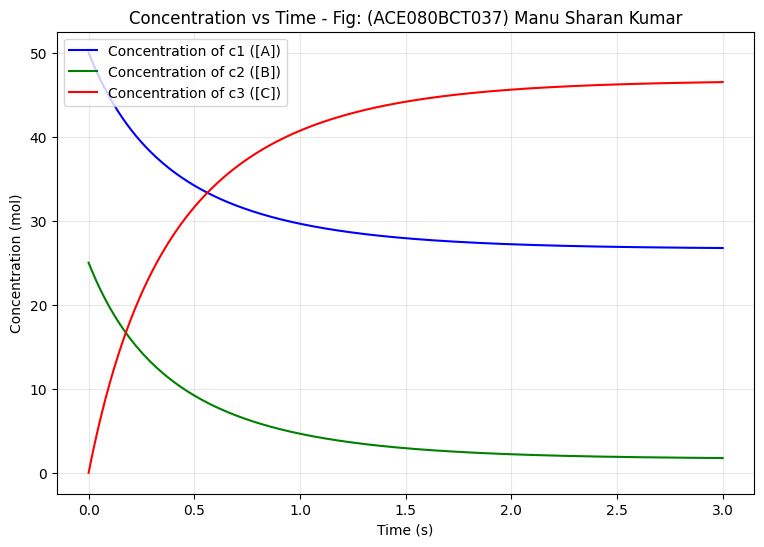

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(time_points, c1, label='Concentration of c1 ([A])', color='blue')
plt.plot(time_points, c2, label='Concentration of c2 ([B])', color='green')
plt.plot(time_points, c3, label='Concentration of c3 ([C])', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time - Fig: (ACE080BCT037) Manu Sharan Kumar')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Reaction 2: Haber–Bosch Ammonia Synthesis

### Theory

The Haber–Bosch process synthesizes ammonia industrially from nitrogen and hydrogen gas:

$$ N_2 + 3H_2 \underset{k_b}{\overset{k_f}{\rightleftharpoons}} 2NH_3 $$

The forward reaction consumes $N_2$ and $H_2$; the backward (decomposition) reaction regenerates
them from $NH_3$. Using the stoichiometry, for every unit of $N_2$ consumed, 3 units of $H_2$ are
consumed and 2 units of $NH_3$ are produced. The simulation below logs the time-evolution of all
three species to a text file and plots the approach to equilibrium.


In [ ]:
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002   # Forward rate constant (scaled for this simulation)
k_b = 0.005    # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)
print('Simulation complete. Log written to industrial_reactor_log.txt')


Simulation complete. Log written to industrial_reactor_log.txt


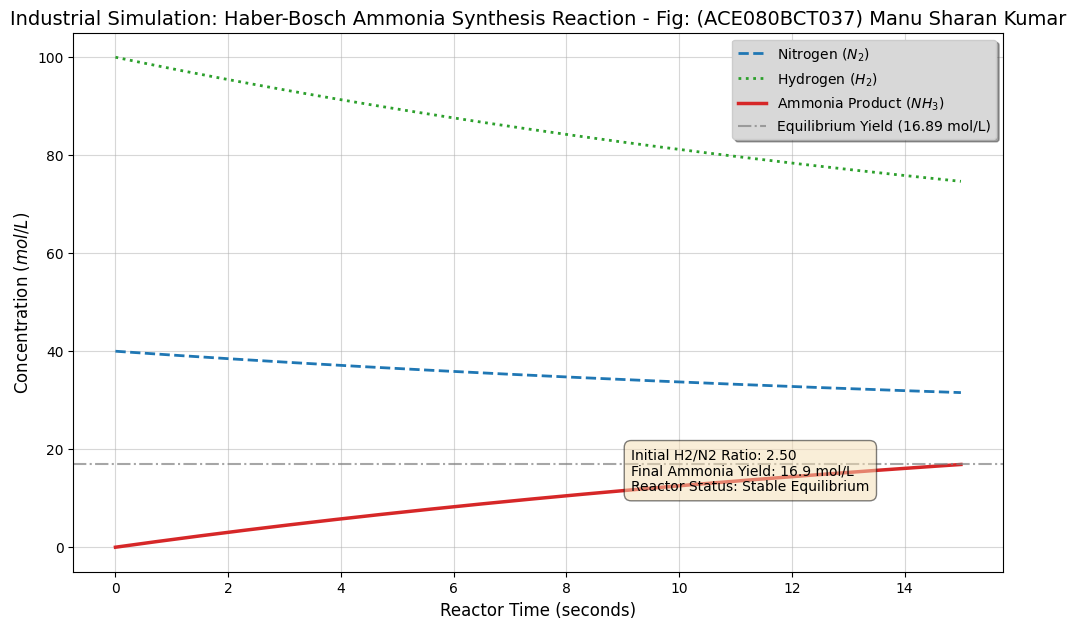

In [ ]:
# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction - Fig: (ACE080BCT037) Manu Sharan Kumar', fontsize=14)
plt.legend(loc='upper right', shadow=True, facecolor="#d8d8d8")
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
               bbox=dict(boxstyle='round', pad=0.5, facecolor='wheat', alpha=0.5))

plt.show()


---
## Reaction 3: Pharmacokinetic Simulation (Oral Single Dose)

### Theory

A common two-compartment pharmacokinetic model describes how a drug taken orally moves between
three "compartments": the gastro-intestinal (GI) tract, the bloodstream (central/plasma
compartment), and the peripheral tissue (the target site):

$$ \frac{dA_{gut}}{dt} = -k_a A_{gut} $$
$$ \frac{dA_{blood}}{dt} = k_a A_{gut} - k_{12} A_{blood} + k_{21} A_{peripheral} - k_e A_{blood} $$
$$ \frac{dA_{peripheral}}{dt} = k_{12} A_{blood} - k_{21} A_{peripheral} $$

where:
- $k_a$ = absorption rate (stomach → bloodstream)
- $k_{12}$ = distribution rate (bloodstream → peripheral tissue)
- $k_{21}$ = redistribution rate (peripheral tissue → bloodstream)
- $k_e$ = elimination rate (drug cleared by liver/kidneys)

The plasma concentration must stay above the **Minimum Effective Concentration (MEC)** for the
drug to work, and below the **Toxic Threshold** to avoid overdose — the "safe therapeutic range".


In [ ]:
# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1     # Time steps in hours
steps = 240  # Simulate for 24 hours

# Initial dose (mg) - single oral dose sits entirely in the GI tract at t=0
dose = 100.0
gut = [dose]
blood = [0.0]
peripheral = [0.0]

for i in range(steps):
    d_gut = -ka * gut[i]
    d_blood = ka * gut[i] - k12 * blood[i] + k21 * peripheral[i] - ke * blood[i]
    d_peripheral = k12 * blood[i] - k21 * peripheral[i]

    gut_next = max(0.0, gut[i] + d_gut * dt)
    blood_next = max(0.0, blood[i] + d_blood * dt)
    peripheral_next = max(0.0, peripheral[i] + d_peripheral * dt)

    gut.append(gut_next)
    blood.append(blood_next)
    peripheral.append(peripheral_next)

time_points = np.arange(0, (steps + 1) * dt, dt)

peak_blood = max(blood)
peak_time = time_points[blood.index(peak_blood)]
print(f"Peak plasma concentration: {peak_blood:.2f} mg at t = {peak_time:.1f} h")
print(f"Final plasma concentration at 24h: {blood[-1]:.2f} mg")
print(f"Final peripheral concentration at 24h: {peripheral[-1]:.2f} mg")


Peak plasma concentration: 45.46 mg at t = 2.5 h
Final plasma concentration at 24h: 7.63 mg
Final peripheral concentration at 24h: 23.88 mg


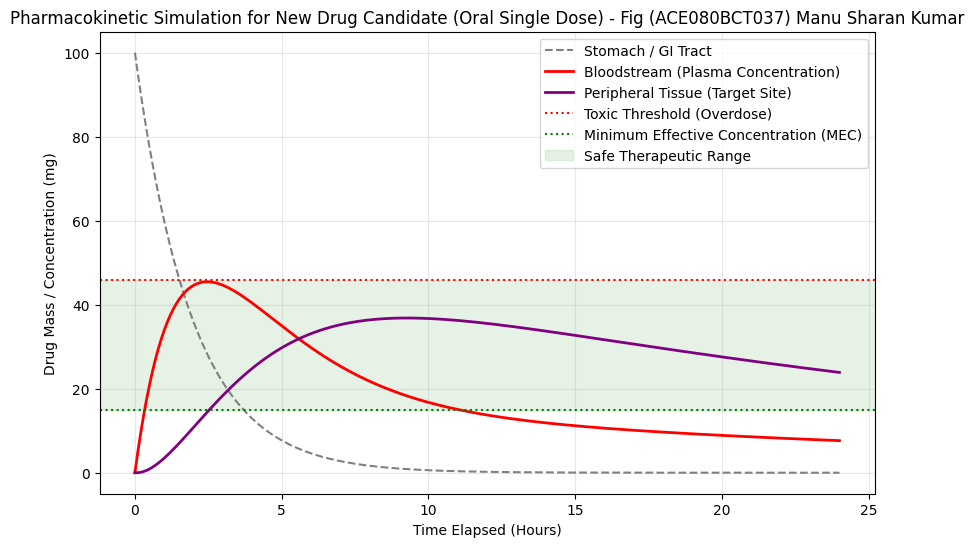

In [ ]:
MEC = 15          # Minimum Effective Concentration
TOXIC = 46         # Toxic threshold (overdose)

plt.figure(figsize=(10, 6))
plt.plot(time_points, gut, '--', color='gray', label='Stomach / GI Tract')
plt.plot(time_points, blood, color='red', linewidth=2, label='Bloodstream (Plasma Concentration)')
plt.plot(time_points, peripheral, color='purple', linewidth=2, label='Peripheral Tissue (Target Site)')

plt.axhline(y=TOXIC, color='red', linestyle=':', linewidth=1.5, label='Toxic Threshold (Overdose)')
plt.axhline(y=MEC, color='green', linestyle=':', linewidth=1.5, label='Minimum Effective Concentration (MEC)')
plt.axhspan(MEC, TOXIC, color='green', alpha=0.1, label='Safe Therapeutic Range')

plt.xlabel('Time Elapsed (Hours)')
plt.ylabel('Drug Mass / Concentration (mg)')
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose) - Fig (ACE080BCT037) Manu Sharan Kumar')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()


---
## Reaction 4: Simulation of Nuclear Fusion (Hydrogen → Helium)

### Theory

Inside a stable star core, hydrogen nuclei fuse (via the proton–proton chain) to form helium:

$$ 4\, ^1H \longrightarrow\ ^4He $$

Four hydrogen nuclei are consumed to produce one helium nucleus. Since the reaction requires four
protons to collide, the fusion rate is modelled as strongly non-linear in the hydrogen
concentration:

$$ \text{fusion\_rate} = k_{fusion} \cdot [H]^2 $$

with stoichiometric updates $\Delta H = -4 \cdot \text{fusion\_rate}\cdot \Delta t$ and
$\Delta He = +1 \cdot \text{fusion\_rate}\cdot \Delta t$.


In [ ]:
# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005
dt = 0.5        # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]       # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)

    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt

    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium

    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)

    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

print(f"Final Hydrogen fuel remaining: {hydrogen[-1]:.2f}%")
print(f"Final Helium ash accumulated : {helium[-1]:.2f}%")


Final Hydrogen fuel remaining: 4.69%
Final Helium ash accumulated : 23.83%


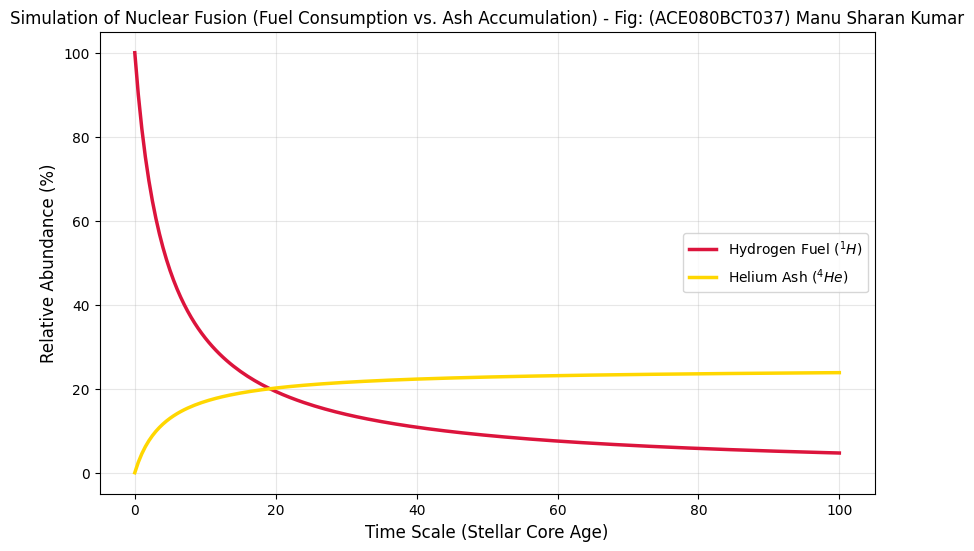

In [ ]:
# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation) - Fig: (ACE080BCT037) Manu Sharan Kumar', fontsize=12)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()


---
## Discussion

In this lab, four different reacting systems were simulated numerically using Euler's method to
integrate their governing rate equations. Reaction 1 illustrated a simple reversible second-order
reaction reaching chemical equilibrium. Reaction 2 modeled the industrial Haber–Bosch ammonia
synthesis, showing $N_2$ and $H_2$ being consumed while $NH_3$ accumulates toward an equilibrium
yield. Reaction 3 modeled the pharmacokinetics of an orally administered drug moving between the
gut, bloodstream, and peripheral tissue compartments, highlighting the importance of staying
within the safe therapeutic range. Reaction 4 modeled nuclear fusion of hydrogen into helium inside
a stellar core, showing the highly non-linear (rate $\propto [H]^2$) depletion of fuel.

## Conclusion

Numerical (Euler-method) simulation provides a simple but powerful way to study the time evolution
of coupled, non-linear rate equations across very different domains — chemistry, industrial
process engineering, pharmacology, and astrophysics — all using the same underlying mathematical
approach: discretize time, compute instantaneous rates, and update concentrations step by step.
